# TUTORIAL-I: Introduction to Bfrescox
**Ozge Surer (Northwestern), Filomena Nunes (Michigan State), Matt Plumlee (Northwestern), Stefan Wild (Argonne)**

## Install `frescox`

In [ ]:
%%bash
cd /content
git clone --branch=development https://github.com/bandframework/bandframework/ 
git clone https://github.com/LLNL/Frescox
mkdir Frescoxex
cp bandframework/software/Bfrescox/makefiles/googlecolab/makefile Frescox/source/
cd Frescox/source
make
make install
make clean

gfortran -Wall -w  -cpp -c -O2  globx7.f
gfortran -Wall -w  -cpp -c -O2  version_number.f
gfortran -Wall -w  -cpp -O1 -c frxx1.f
gfortran -Wall -w  -cpp -c -O2  frxx2.f
gfortran -Wall -w  -cpp -c -O2  frxx3.f
gfortran -Wall -w  -cpp -c -O2  frxx3b.f
gfortran -Wall -w  -cpp -c -O2  f14arm64.f
gfortran -Wall -w  -cpp -c -O2  frxx0.f
gfortran -Wall -w  -cpp -c -O2  frxx4.f
gfortran -Wall -w  -cpp -c -O2  frxx7a.f
gfortran -Wall -w  -cpp -c -O2  frxx5.f
gfortran -Wall -w  -cpp -c -O2  frxx6.f
gfortran -Wall -w  -cpp -c -O2  erwinrc4.f
gfortran -Wall -w  -cpp -c -O2  frxx7b.f
gfortran -Wall -w  -cpp -c -O2  frxx8.f
gfortran -Wall -w  -cpp -c -O2  frxx9.f
gfortran -Wall -w  -cpp -c -O2  frxx10.f
gfortran -Wall -w  -cpp -c -O2  frxx11.f
gfortran -Wall -w  -cpp -c -O2  bincc.f
gfortran -Wall -w  -cpp -c -O2  frxx13.f
gfortran -Wall -w  -cpp -c -O2  frxx16.f
gfortran -Wall -w  -cpp -c -O2  frxx17.f
gfortran -Wall -w  -cpp -c -O2  frxx21.f
gfortran -Wall -w  -cpp -c -O2  lagmesh.f
gfortran -Wall

fatal: destination path 'bandframework' already exists and is not an empty directory.
fatal: destination path 'Frescox' already exists and is not an empty directory.
mkdir: cannot create directory ‘Frescoxex’: File exists


## Interfacing frescox with the $\chi^2$ minimization wrapper

In this section, we interface with ``frescox`` - the $\chi^2$ minimization wrapper for frescox. 

The wrapper fits based on the statistics of the Chi-squared function
$\chi^2 = \sum_{i=1}^n \bigg(\frac{\hat{f}_i(\theta) - y_i}{\sigma_i}\bigg)^2$, where
$\sigma_i$ is the standard deviation associated with each measurement.

In this case, we need a few extra files.

The simplest example is just elastic scattering of neutrons on 48Ca, 48Ca(n,n)48Ca.  To run `frescox`, three files are needed:

- ``48Ca.in`` - frescox input file
- ``search-el.in`` - sfresco set up file (contains the parameters that are being optimized and the experimental data)
- ``sfresco.in`` - sfresco input file

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pylab
import subprocess

commands = '''
  export PATH=$PATH:/content/Frescoxex
  cd /content/bandframework/software/Bfrescox/Tutorial_I/python_scripts
  mkdir frescox_outputs
  frescox < frescox_inputs/48Ca.in frescox_inputs/search-el.in frescox_inputs/sfresco.in > frescox_outputs/48Ca.out
'''

# Execute frescox
bashresults = subprocess.run(commands, capture_output=True, shell=True)

# Read outputs
os.chdir("/content/bandframework/software/Bfrescox/Tutorial_I/python_scripts")
files = ['frescox_outputs/48Ca.out']
outs = []
for file in files:
    with open(file) as f:
        content = f.readlines()
        outs.append(content)
        
slist = []
for out in outs:
    sigma_omega_ratio = [] 
    for idline, line in enumerate(out):
        if ('X-S' in line):
            sigma_omega_ratio.append(float(line.split()[4]))

    slist.append(sigma_omega_ratio)

## Observe the fit along with data

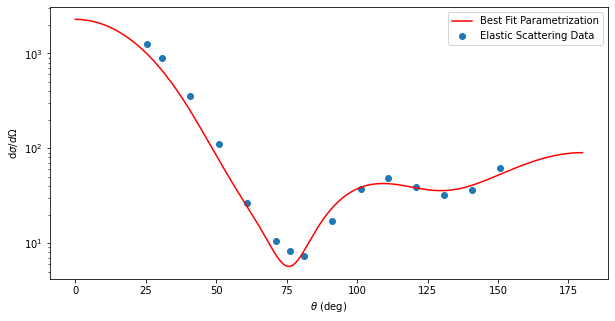

In [ ]:
# Observed data
data = np.array([[25.5, 1243], 
                 [30.6, 887.7],               
                 [40.8, 355.5],               
                 [50.9, 111.5],               
                 [61, 26.5],             
                 [71.1, 10.4],           
                 [76.2, 8.3],             
                 [81.2, 7.3],             
                 [91.2, 17.2],             
                 [101.2, 37.6],              
                 [111.1, 48.7],                
                 [121, 38.9],              
                 [130.9, 32.4],               
                 [140.8, 36.4],               
                 [150.6, 61.9]])

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
line, = ax.plot(slist[0], color='red', label='Best Fit Parametrization')
ax.scatter(data[:,0], data[:,1], label='Elastic Scattering Data')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel(r'd$\sigma/d\Omega$')
plt.legend()
ax.set_yscale('log')

pylab.show()